<a href="https://colab.research.google.com/github/mdjawadulhasan/Visual-AI/blob/main/DIE_MDAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install -q MDAnalysis MDAnalysisTests


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 MB 17.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.0 MB/s eta 0:00:00


In [ ]:
import MDAnalysis as mda
from MDAnalysis.tests.datafiles import PSF, DCD

u = mda.Universe(PSF, DCD)
protein = u.select_atoms("protein")

print("Atoms in the protein:", protein.n_atoms)
print("Residues in the protein:", protein.n_residues)

first_residue = protein.residues[0]

print("\nFirst residue:")
print("Name:", first_residue.resname)
print("Residue number:", first_residue.resid)
print("Number of atoms:", first_residue.atoms.n_atoms)
print("Atom names:", first_residue.atoms.names)

Atoms in the protein: 3341
Residues in the protein: 214

First residue:
Name: MET
Residue number: 1
Number of atoms: 19
Atom names: ['N' 'HT1' 'HT2' 'HT3' 'CA' 'HA' 'CB' 'HB1' 'HB2' 'CG' 'HG1' 'HG2' 'SD'
 'CE' 'HE1' 'HE2' 'HE3' 'C' 'O']


/usr/local/lib/python3.13/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


In [ ]:
# Select the first frame: one snapshot of the molecule
u.trajectory[0]

# Select the first residue in the protein
# Python indexing starts at 0
first_residue = protein.residues[0]

# Get its coordinate array
# Each row is an atom; the three columns are x, y and z
# For 19 atoms, the shape is (19, 3)
print("Coordinate array shape:", first_residue.atoms.positions.shape)

# Print each atom's name and its [x, y, z] coordinates
# MDAnalysis normally expresses these coordinates in ångströms (Å)
for atom in first_residue.atoms:
    print(atom.name, atom.position)

Coordinate array shape: (19, 3)
N [ 11.736044   8.500797 -10.445281]
HT1 [ 12.365119   7.839936 -10.834842]
HT2 [ 12.0919485   9.441535  -10.724611 ]
HT3 [ 10.831957   8.308614 -10.963931]
CA [11.664622  8.393473 -8.983231]
HA [12.672612  8.560489 -8.680764]
CB [10.739638  9.569928 -8.590751]
HB1 [ 9.63879   9.270485 -8.967953]
HB2 [11.094614 10.518884 -9.141996]
CG [10.556571  9.934239 -7.112363]
HG1 [11.449215  10.322626  -6.6931505]
HG2 [10.2771435  8.978575  -6.5972548]
SD [ 9.24967   11.104844  -6.9101005]
CE [10.443903 12.492348 -7.161938]
HE1 [11.472447  12.294425  -7.6610537]
HE2 [10.565218  13.067866  -6.2516317]
HE3 [ 9.883093 13.17239  -7.789969]
C [11.166548  7.128996 -8.374827]
O [10.151079   6.6486216 -8.755143 ]


In [ ]:
print("Topology file:", PSF)
print("Trajectory file:", DCD)

# Select the first atom belonging to the protein
first_atom = protein.atoms[0]

# These describe the atom's identity and residue membership
# They come from the topology
print("\nAtom name:", first_atom.name)
print("Residue name:", first_atom.resname)
print("Residue number:", first_atom.resid)

# Read the atom's position in the first recorded frame
u.trajectory[0]

# Copy the coordinates so we preserve this snapshot
position_frame_0 = first_atom.position.copy()
print("\nPosition in frame 0:", position_frame_0)

# Move to the next recorded frame
u.trajectory[1]

# It is still the same atom, but we now read its new position
position_frame_1 = first_atom.position.copy()
print("Position in frame 1:", position_frame_1)

# Check that moving between frames did not change its identity
print("\nAtom name after changing frame:", first_atom.name)
print("Residue name after changing frame:", first_atom.resname)

Topology file: /usr/local/lib/python3.13/dist-packages/MDAnalysisTests/data/adk.psf
Trajectory file: /usr/local/lib/python3.13/dist-packages/MDAnalysisTests/data/adk_dims.dcd

Atom name: N
Residue name: MET
Residue number: 1

Position in frame 0: [ 11.736044   8.500797 -10.445281]
Position in frame 1: [ 11.505546   8.062977 -10.38611 ]

Atom name after changing frame: N
Residue name after changing frame: MET


In [ ]:
print("Number of frames:", len(u.trajectory))

# Read the time interval between saved frames
# MDAnalysis normally expresses time in picoseconds (ps)
print("Time between frames (ps):", u.trajectory.dt)

# Examine the first five saved snapshots
# [:5] selects frame indices 0, 1, 2, 3 and 4
for ts in u.trajectory[:5]:

    # ts is a Timestep object describing the current snapshot
    # Moving through the loop updates the atoms' current coordinates
    print(
        "Frame:", ts.frame,
        "| Time (ps):", round(ts.time, 3),
        "| First atom position:", protein.atoms[0].position.copy()
    )

# Inspect the first and last recorded times
u.trajectory[0]
first_time = u.trajectory.time

# Python index -1 means the last item
u.trajectory[-1]
last_time = u.trajectory.time

print("\nFirst recorded time (ps):", first_time)
print("Last recorded time (ps):", last_time)

# Subtract the endpoints to get the time spanned by saved snapshots
print("Recorded time span (ps):", last_time - first_time)

Number of frames: 98
Time between frames (ps): 0.9999999119200186
Frame: 0 | Time (ps): 1.0 | First atom position: [ 11.736044   8.500797 -10.445281]
Frame: 1 | Time (ps): 2.0 | First atom position: [ 11.505546   8.062977 -10.38611 ]
Frame: 2 | Time (ps): 3.0 | First atom position: [ 11.694641   8.390831 -10.681395]
Frame: 3 | Time (ps): 4.0 | First atom position: [ 11.616836   8.354407 -10.223578]
Frame: 4 | Time (ps): 5.0 | First atom position: [12.507129  8.750157 -8.96329 ]

First recorded time (ps): 0.9999999119200186
Last recorded time (ps): 97.99999136816182
Recorded time span (ps): 96.9999914562418


In [ ]:
# Select all atoms recognized as belonging to a protein
protein = u.select_atoms("protein")

# Select the protein's backbone atoms
# "and" requires atoms to satisfy both conditions
backbone = u.select_atoms("protein and backbone")

# Select only protein atoms whose name is CA
# These are the alpha carbons
alpha_carbons = u.select_atoms("protein and name CA")

# Select protein atoms belonging to residue numbers 10 through 20
# Both endpoints are included
region = u.select_atoms("protein and resid 10:20")

# Compare how many atoms each selection contains
print("All protein atoms:", protein.n_atoms)
print("Backbone atoms:", backbone.n_atoms)
print("Alpha-carbon atoms:", alpha_carbons.n_atoms)
print("Atoms in residues 10–20:", region.n_atoms)

# Count the residues represented in the selected region
print("Residues in the region:", region.n_residues)

# Show the names of the first eight backbone atoms
print("\nFirst eight backbone atom names:", backbone.names[:8])

All protein atoms: 3341
Backbone atoms: 855
Alpha-carbon atoms: 214
Atoms in residues 10–20: 150
Residues in the region: 11

First eight backbone atom names: ['N' 'CA' 'C' 'O' 'N' 'CA' 'C' 'O']


In [ ]:
first_residue = protein.residues[0]

# Select its alpha carbon using the atom name CA
first_residue_ca = first_residue.atoms.select_atoms("name CA")

# Compare all atom names with the single representative atom
print("Residue:", first_residue.resname, first_residue.resid)
print("All atom names:", first_residue.atoms.names)
print("Alpha-carbon atom name:", first_residue_ca.names)

# Compare the number of coordinate points
print("\nAll atoms coordinate shape:", first_residue.atoms.positions.shape)
print("Alpha-carbon coordinate shape:", first_residue_ca.positions.shape)

Residue: MET 1
All atom names: ['N' 'HT1' 'HT2' 'HT3' 'CA' 'HA' 'CB' 'HB1' 'HB2' 'CG' 'HG1' 'HG2' 'SD'
 'CE' 'HE1' 'HE2' 'HE3' 'C' 'O']
Alpha-carbon atom name: ['CA']

All atoms coordinate shape: (19, 3)
Alpha-carbon coordinate shape: (1, 3)


In [ ]:
import numpy as np

# Select the alpha carbon in each residue
# Each selection should contain exactly one atom
ca_10 = u.select_atoms("protein and resid 10 and name CA")
ca_20 = u.select_atoms("protein and resid 20 and name CA")

print("Atoms selected in residue 10:", ca_10.n_atoms)
print("Atoms selected in residue 20:", ca_20.n_atoms)

# Check that we have exactly one atom in each selection
assert ca_10.n_atoms == 1 and ca_20.n_atoms == 1

# Select the first saved snapshot
u.trajectory[0]

# positions[0] gives the [x, y, z] coordinates of the selected atom
position_10 = ca_10.positions[0].copy()
position_20 = ca_20.positions[0].copy()

# Subtract the coordinates to get the displacement vector
# This contains the separation along x, y and z
displacement = position_20 - position_10

# The vector's length is the straight-line distance between the atoms
distance = np.linalg.norm(displacement)

print("\nResidue 10 CA position:", position_10)
print("Residue 20 CA position:", position_20)
print("Displacement vector:", displacement)
print("Distance (Å):", distance)

Atoms selected in residue 10: 1
Atoms selected in residue 20: 1

Residue 10 CA position: [-5.3477697  1.3352463  6.590974 ]
Residue 20 CA position: [ 1.6873744 10.048397  -7.306483 ]
Displacement vector: [  7.035144   8.713151 -13.897457]
Distance (Å): 17.848013


Number of measurements: 98
Minimum distance (Å): 16.874693
Maximum distance (Å): 19.62235
Mean distance (Å): 18.05163


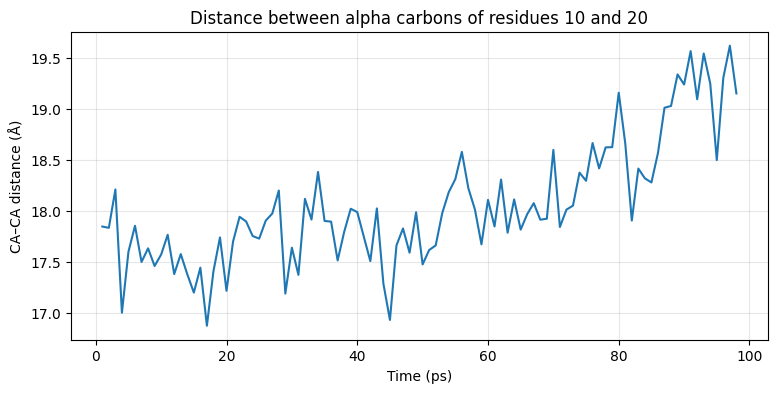

In [ ]:
import matplotlib.pyplot as plt

# Start empty lists to collect one time and one distance per frame
times = []
distances = []

# Visit every saved frame in order
# MDAnalysis updates the selected atoms' coordinates at each frame
for ts in u.trajectory:

    # Calculate the displacement using this frame's coordinates
    displacement = ca_20.positions[0] - ca_10.positions[0]

    # Convert the displacement into a single distance in ångströms
    distance = np.linalg.norm(displacement)

    # Save the current time and calculated distance
    times.append(ts.time)
    distances.append(distance)

# Convert the lists into NumPy arrays for numerical operations
times = np.array(times)
distances = np.array(distances)

# There should be one measurement for each of the 98 frames
print("Number of measurements:", len(distances))
print("Minimum distance (Å):", distances.min())
print("Maximum distance (Å):", distances.max())
print("Mean distance (Å):", distances.mean())

# Plot time horizontally and distance vertically
plt.figure(figsize=(9, 4))
plt.plot(times, distances)
plt.xlabel("Time (ps)")
plt.ylabel("CA–CA distance (Å)")
plt.title("Distance between alpha carbons of residues 10 and 20")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
min_index = np.argmin(distances)
max_index = np.argmax(distances)

# We analysed every frame in order, so these indices match frame indices
# times[index] retrieves the time associated with each measurement
print(
    f"Minimum: {distances[min_index]:.2f} Å "
    f"at frame {min_index}, time {times[min_index]:.2f} ps"
)

print(
    f"Maximum: {distances[max_index]:.2f} Å "
    f"at frame {max_index}, time {times[max_index]:.2f} ps"
)

# Independently revisit the frame with the maximum distance
u.trajectory[int(max_index)]

# Recalculate directly from that frame's atom coordinates
recalculated = np.linalg.norm(
    ca_20.positions[0] - ca_10.positions[0]
)

# Compare the recalculated value with the stored measurement
# isclose allows for small numerical differences
print("Recalculated maximum (Å):", recalculated)
print("Values agree:", np.isclose(recalculated, distances[max_index]))

Minimum: 16.87 Å at frame 16, time 17.00 ps
Maximum: 19.62 Å at frame 96, time 97.00 ps
Recalculated maximum (Å): 19.62235
Values agree: True


Minimum Rg: 16.67 Å
Maximum Rg: 19.59 Å
Mean Rg: 18.27 Å


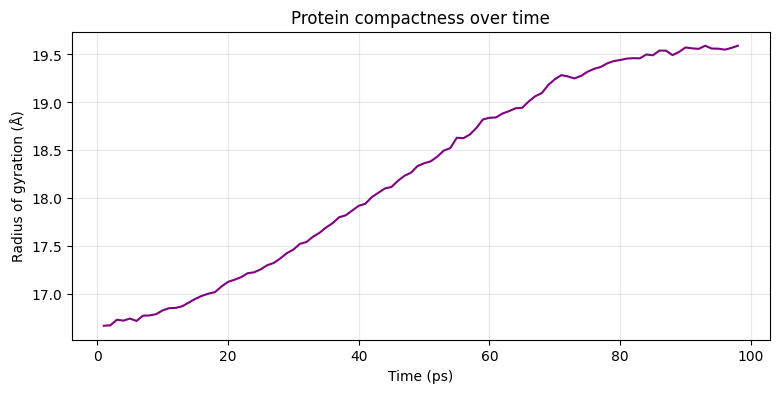

In [ ]:
protein = u.select_atoms("protein")

# Collect a time and radius of gyration for every saved frame
rg_times = []
rg_values = []

for ts in u.trajectory:

    # Calculate the mass-weighted spread around the centre of mass
    # The result is a single length, expressed in ångströms
    rg = protein.radius_of_gyration()

    rg_times.append(ts.time)
    rg_values.append(rg)

# Convert the collected values into NumPy arrays
rg_times = np.array(rg_times)
rg_values = np.array(rg_values)

print(f"Minimum Rg: {rg_values.min():.2f} Å")
print(f"Maximum Rg: {rg_values.max():.2f} Å")
print(f"Mean Rg: {rg_values.mean():.2f} Å")

# Plot how the protein's overall spread changes over time
plt.figure(figsize=(9, 4))
plt.plot(rg_times, rg_values, color="purple")
plt.xlabel("Time (ps)")
plt.ylabel("Radius of gyration (Å)")
plt.title("Protein compactness over time")
plt.grid(alpha=0.3)
plt.show()

Minimum Rg: 16.67 Å
Maximum Rg: 19.59 Å
Mean Rg: 18.27 Å


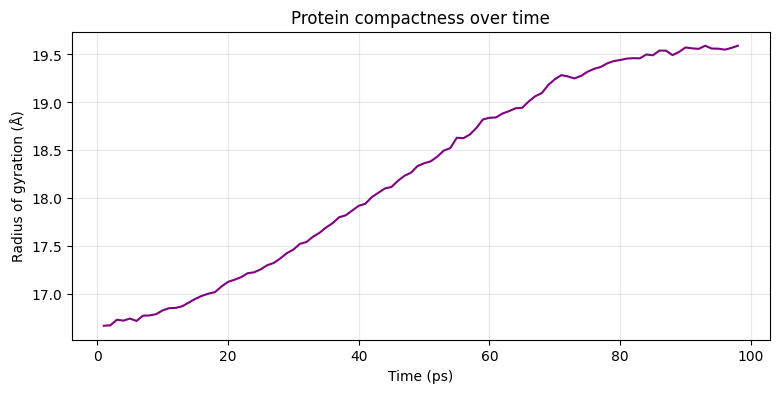

In [ ]:
protein = u.select_atoms("protein")

# Collect a time and radius of gyration for every saved frame
rg_times = []
rg_values = []

for ts in u.trajectory:

    # Calculate the mass-weighted spread around the centre of mass
    # The result is a single length, expressed in ångströms
    rg = protein.radius_of_gyration()

    rg_times.append(ts.time)
    rg_values.append(rg)

# Convert the collected values into NumPy arrays
rg_times = np.array(rg_times)
rg_values = np.array(rg_values)

print(f"Minimum Rg: {rg_values.min():.2f} Å")
print(f"Maximum Rg: {rg_values.max():.2f} Å")
print(f"Mean Rg: {rg_values.mean():.2f} Å")

# Plot how the protein's overall spread changes over time
plt.figure(figsize=(9, 4))
plt.plot(rg_times, rg_values, color="purple")
plt.xlabel("Time (ps)")
plt.ylabel("Radius of gyration (Å)")
plt.title("Protein compactness over time")
plt.grid(alpha=0.3)
plt.show()

Minimum Rg: 16.67 Å
Maximum Rg: 19.59 Å
Mean Rg: 18.27 Å


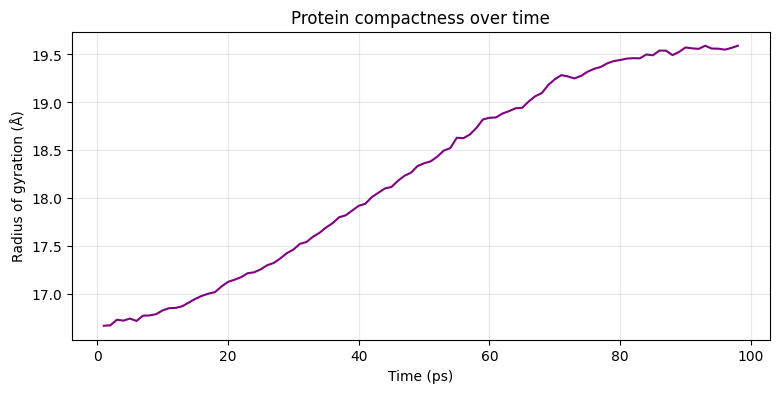

In [ ]:
protein = u.select_atoms("protein")

# Collect a time and radius of gyration for every saved frame
rg_times = []
rg_values = []

for ts in u.trajectory:

    # Calculate the mass-weighted spread around the centre of mass
    # The result is a single length, expressed in ångströms
    rg = protein.radius_of_gyration()

    rg_times.append(ts.time)
    rg_values.append(rg)

# Convert the collected values into NumPy arrays
rg_times = np.array(rg_times)
rg_values = np.array(rg_values)

print(f"Minimum Rg: {rg_values.min():.2f} Å")
print(f"Maximum Rg: {rg_values.max():.2f} Å")
print(f"Mean Rg: {rg_values.mean():.2f} Å")

# Plot how the protein's overall spread changes over time
plt.figure(figsize=(9, 4))
plt.plot(rg_times, rg_values, color="purple")
plt.xlabel("Time (ps)")
plt.ylabel("Radius of gyration (Å)")
plt.title("Protein compactness over time")
plt.grid(alpha=0.3)
plt.show()

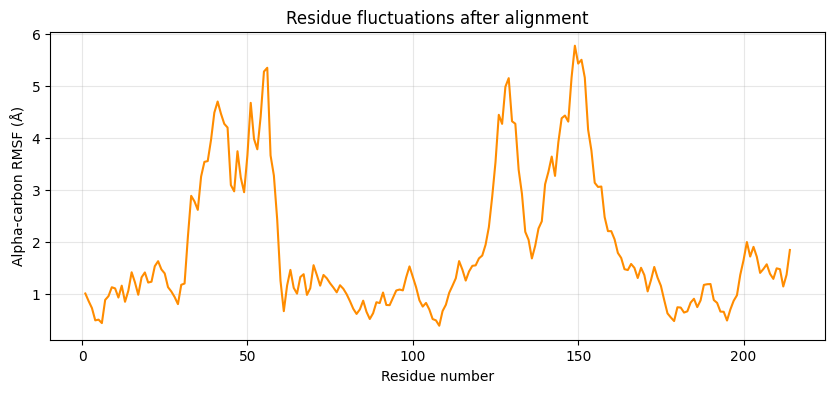

Five residues with the highest alpha-carbon RMSF:
THR 149: 5.77 Å
GLU 151: 5.50 Å
GLY 150: 5.43 Å
GLY 56: 5.35 Å
ALA 55: 5.27 Å


In [ ]:
from MDAnalysis.analysis import align, rms

# Load a fresh copy so this exercise is independent of previous cells
mobile = mda.Universe(PSF, DCD)

# Use alpha carbons to fit the structures
selection = "protein and name CA"

# Build an average reference:
# first fit frames to frame 0, then average the fitted coordinates
average = align.AverageStructure(
    mobile,
    mobile,
    select=selection,
    ref_frame=0
).run()

# The resulting Universe contains the average reference coordinates
average_reference = average.results.universe

# Align every frame to the average reference
# in_memory=True keeps the aligned coordinates in this working Universe
# It does not overwrite the original trajectory file
align.AlignTraj(
    mobile,
    average_reference,
    select=selection,
    in_memory=True
).run()

# Select one alpha carbon per residue
ca = mobile.select_atoms(selection)

# Calculate each selected atom's fluctuations around its average position
# RMSF itself does not perform alignment, so we aligned above
rmsf_analysis = rms.RMSF(ca).run()

# Each value corresponds to one alpha carbon in the selection
rmsf_values = rmsf_analysis.results.rmsf
residue_numbers = ca.resids

plt.figure(figsize=(10, 4))
plt.plot(residue_numbers, rmsf_values, color="darkorange")
plt.xlabel("Residue number")
plt.ylabel("Alpha-carbon RMSF (Å)")
plt.title("Residue fluctuations after alignment")
plt.grid(alpha=0.3)
plt.show()

# Sort array indices by RMSF, then take the five largest in descending order
top_indices = np.argsort(rmsf_values)[-5:][::-1]

print("Five residues with the highest alpha-carbon RMSF:")
for index in top_indices:
    print(
        f"{ca.resnames[index]} {ca.resids[index]}: "
        f"{rmsf_values[index]:.2f} Å"
    )

In [ ]:
import MDAnalysis as mda
from MDAnalysis.tests.datafiles import PSF, DCD
from MDAnalysis.analysis import rms

# Load the trajectory we want to analyse
u = mda.Universe(PSF, DCD)

# Load a separate copy to provide a fixed reference
reference = mda.Universe(PSF, DCD)
reference.trajectory[0]

# Compare each frame's alpha carbons with those in reference frame 0
# The calculation accounts for overall translation and rotation
rmsd_analysis = rms.RMSD(
    u,
    reference,
    select="protein and name CA",
    ref_frame=0
).run()

# Create the variables needed by the export cell
# Columns contain frame number, time in ps and RMSD in Å
rmsd_results = rmsd_analysis.results.rmsd
rmsd_times = rmsd_results[:, 1]
rmsd_values = rmsd_results[:, 2]

# Confirm that the results now exist
print("Results shape:", rmsd_results.shape)
print("First five rows:")
print(rmsd_results[:5])

Results shape: (98, 3)
First five rows:
[[0.00000000e+00 9.99999912e-01 3.68780704e-07]
 [1.00000000e+00 1.99999982e+00 4.23430296e-01]
 [2.00000000e+00 2.99999974e+00 5.93658621e-01]
 [3.00000000e+00 3.99999965e+00 7.36831301e-01]
 [4.00000000e+00 4.99999956e+00 8.27720321e-01]]


/usr/local/lib/python3.13/dist-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


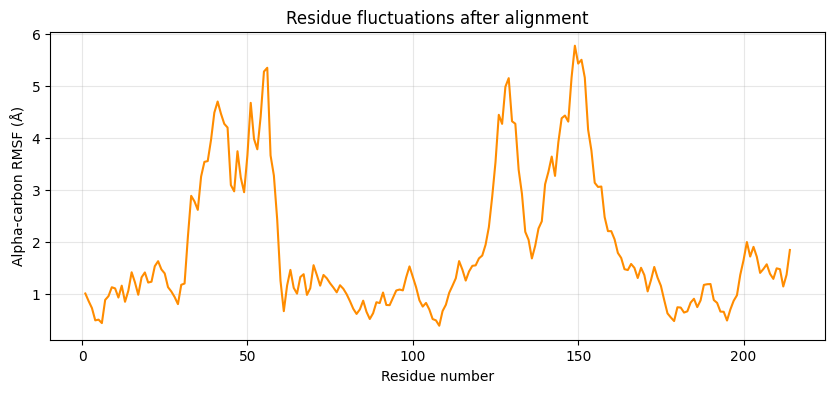

Number of alpha carbons analysed: 214

Five residues with the highest alpha-carbon RMSF:
THR 149: 5.77 Å
GLU 151: 5.50 Å
GLY 150: 5.43 Å
GLY 56: 5.35 Å
ALA 55: 5.27 Å


In [ ]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from MDAnalysis.tests.datafiles import PSF, DCD
from MDAnalysis.analysis import align, rms

# Load a fresh copy of the sample topology and trajectory
mobile = mda.Universe(PSF, DCD)

# Use one alpha carbon per protein residue
selection = "protein and name CA"

# Construct an average reference structure:
# fit each frame to frame 0, then average the fitted coordinates
average = align.AverageStructure(
    mobile,
    mobile,
    select=selection,
    ref_frame=0
).run()

average_reference = average.results.universe

# Align all frames to the average reference
# This removes overall translation and rotation before measuring fluctuations
# The aligned coordinates stay in memory; the original file is unchanged
align.AlignTraj(
    mobile,
    average_reference,
    select=selection,
    in_memory=True
).run()

# Select the alpha carbons from the aligned trajectory
ca = mobile.select_atoms(selection)

# RMSF measures each atom's fluctuations around its average position
# RMSF does not align frames automatically
rmsf_analysis = rms.RMSF(ca).run()

# Store values for plotting and later export
# Each RMSF value corresponds to one selected alpha carbon
rmsf_values = rmsf_analysis.results.rmsf
residue_numbers = ca.resids

# Plot residue number against fluctuation in ångströms
plt.figure(figsize=(10, 4))
plt.plot(residue_numbers, rmsf_values, color="darkorange")
plt.xlabel("Residue number")
plt.ylabel("Alpha-carbon RMSF (Å)")
plt.title("Residue fluctuations after alignment")
plt.grid(alpha=0.3)
plt.show()

# Find the five largest RMSF values, ordered from highest to lowest
top_indices = np.argsort(rmsf_values)[-5:][::-1]

print("Number of alpha carbons analysed:", ca.n_atoms)
print("\nFive residues with the highest alpha-carbon RMSF:")

for index in top_indices:
    print(
        f"{ca.resnames[index]} {ca.resids[index]}: "
        f"{rmsf_values[index]:.2f} Å"
    )